# Calgary Housing Price EDA

Exploratory analysis of Calgary housing prices vs oil prices, interest rates, and economic indicators.

**Key hypothesis**: Calgary housing is a leveraged bet on oil — when oil spikes, housing follows with a 6-12 month lag.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load merged datasets
annual = pd.read_csv('../data/processed/annual_merged.csv', parse_dates=['assessment_date'])
monthly = pd.read_csv('../data/processed/creb_monthly.csv', parse_dates=['date'])

print(f'Annual panel: {len(annual)} rows ({annual.roll_year.min()}–{annual.roll_year.max()})')
print(f'Monthly CREB: {len(monthly)} rows')
annual.head()

Annual panel: 21 rows (2005–2025)
Monthly CREB: 70 rows


,roll_year,assessment_date,avg_assessed_value,property_count,reference_year,oil_price_avg,overnight_rate_avg,bond_yield_avg,cadusd_avg,natgas_avg,alberta_etf_avg,oil_price_dec,overnight_rate_dec,price_yoy_pct,next_year_price,next_year_yoy_pct
0,2005,2005-01-01,244908.0,331928,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,267775.0,9.336976
1,2006,2006-01-01,267775.0,344981,2005,57.767273,2.657658,4.385833,0.827795,9.418909,9.938410,61.040001,3.2437,9.336976,386450.0,44.318924
2,2007,2007-01-01,386450.0,356552,2006,67.694000,4.019875,4.299167,0.885448,6.797000,12.635524,61.049999,4.2482,44.318924,480304.0,24.286195
3,2008,2008-01-01,480304.0,369116,2007,75.541001,4.344708,4.335000,0.941446,7.285800,12.980461,95.980003,4.2597,24.286195,459267.0,-4.379934
4,2009,2009-01-01,459267.0,382996,2008,94.818181,2.957742,4.040000,0.940267,8.500182,13.432448,44.599998,1.5017,-4.379934,402069.0,-12.454193


## 1. Price History

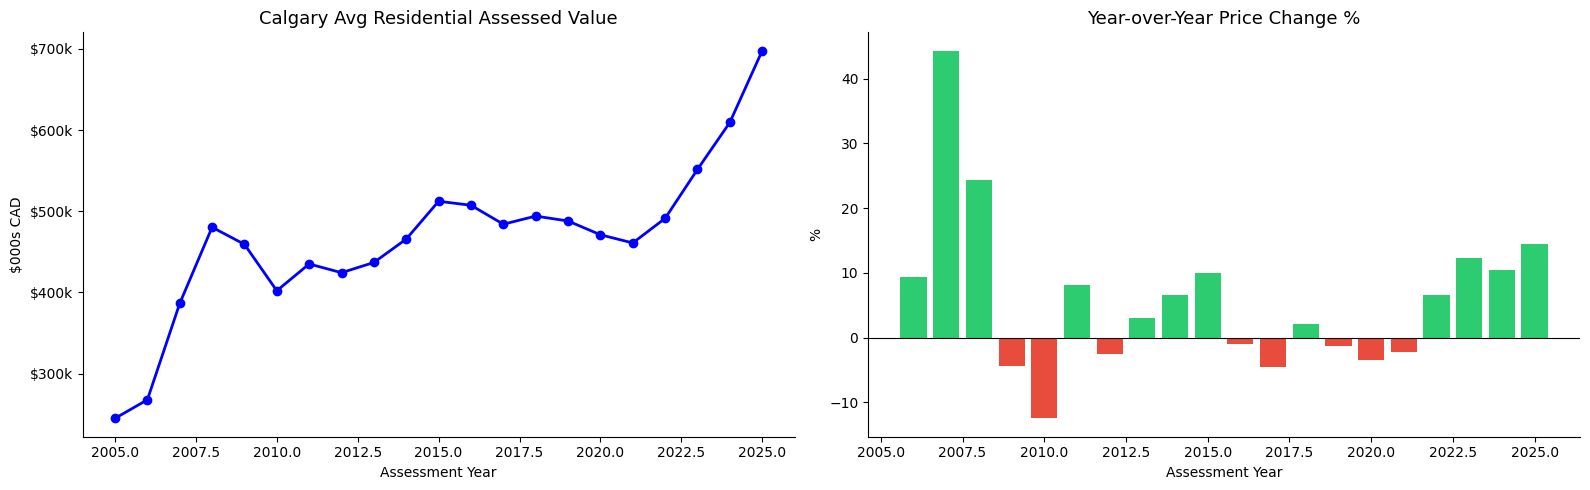

Peak YoY gain: 44.3% in 2007
Worst YoY drop: -12.5% in 2010


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Assessed value over time
ax = axes[0]
ax.plot(annual['roll_year'], annual['avg_assessed_value'] / 1000, 'b-o', linewidth=2)
ax.set_title('Calgary Avg Residential Assessed Value', fontsize=13)
ax.set_ylabel('$000s CAD')
ax.set_xlabel('Assessment Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:.0f}k'))

# YoY change
ax = axes[1]
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in annual['price_yoy_pct'].fillna(0)]
ax.bar(annual['roll_year'], annual['price_yoy_pct'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year-over-Year Price Change %', fontsize=13)
ax.set_ylabel('%')
ax.set_xlabel('Assessment Year')

plt.tight_layout()
plt.show()

print(f"Peak YoY gain: {annual['price_yoy_pct'].max():.1f}% in {annual.loc[annual['price_yoy_pct'].idxmax(), 'roll_year']}")
print(f"Worst YoY drop: {annual['price_yoy_pct'].min():.1f}% in {annual.loc[annual['price_yoy_pct'].idxmin(), 'roll_year']}")

## 2. Oil Price vs Housing

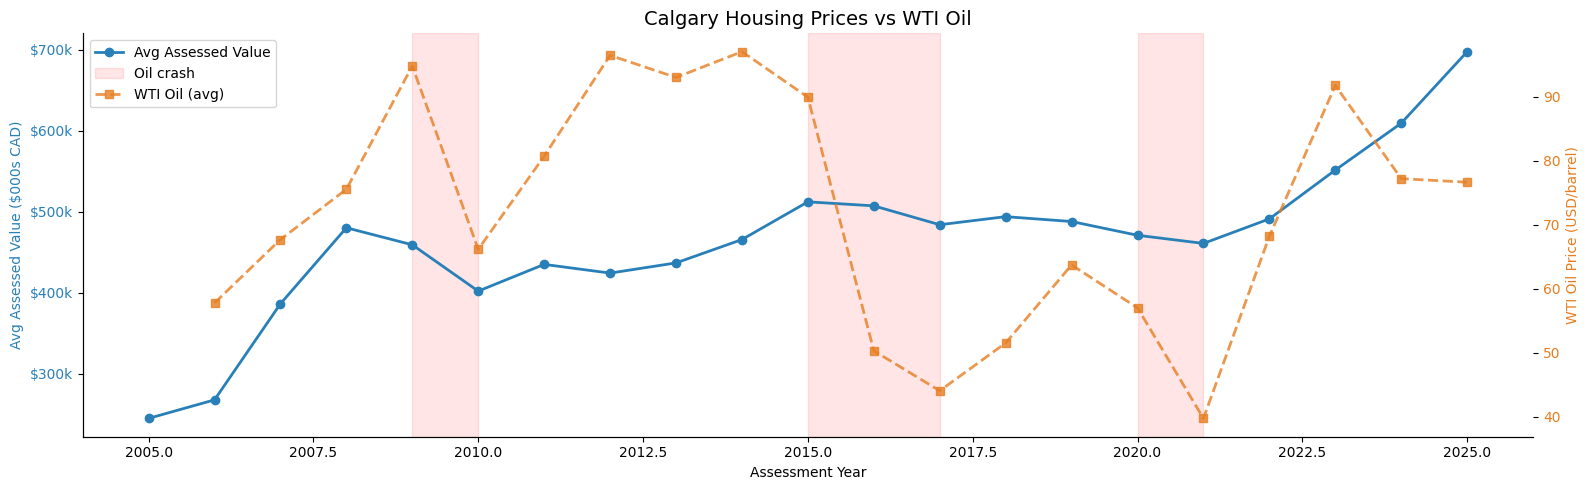

In [3]:
fig, ax1 = plt.subplots(figsize=(16, 5))

# Housing prices
color1 = '#2980b9'
ax1.plot(annual['roll_year'], annual['avg_assessed_value'] / 1000, 'o-', color=color1, linewidth=2, label='Avg Assessed Value')
ax1.set_ylabel('Avg Assessed Value ($000s CAD)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:.0f}k'))

# Oil price on secondary axis
ax2 = ax1.twinx()
color2 = '#e67e22'
ax2.plot(annual['roll_year'], annual['oil_price_avg'], 's--', color=color2, linewidth=2, alpha=0.8, label='WTI Oil (avg)')
ax2.set_ylabel('WTI Oil Price (USD/barrel)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Shade oil crash periods
ax1.axvspan(2009, 2010, alpha=0.1, color='red', label='Oil crash')
ax1.axvspan(2015, 2017, alpha=0.1, color='red')
ax1.axvspan(2020, 2021, alpha=0.1, color='red')

ax1.set_title('Calgary Housing Prices vs WTI Oil', fontsize=14)
ax1.set_xlabel('Assessment Year')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

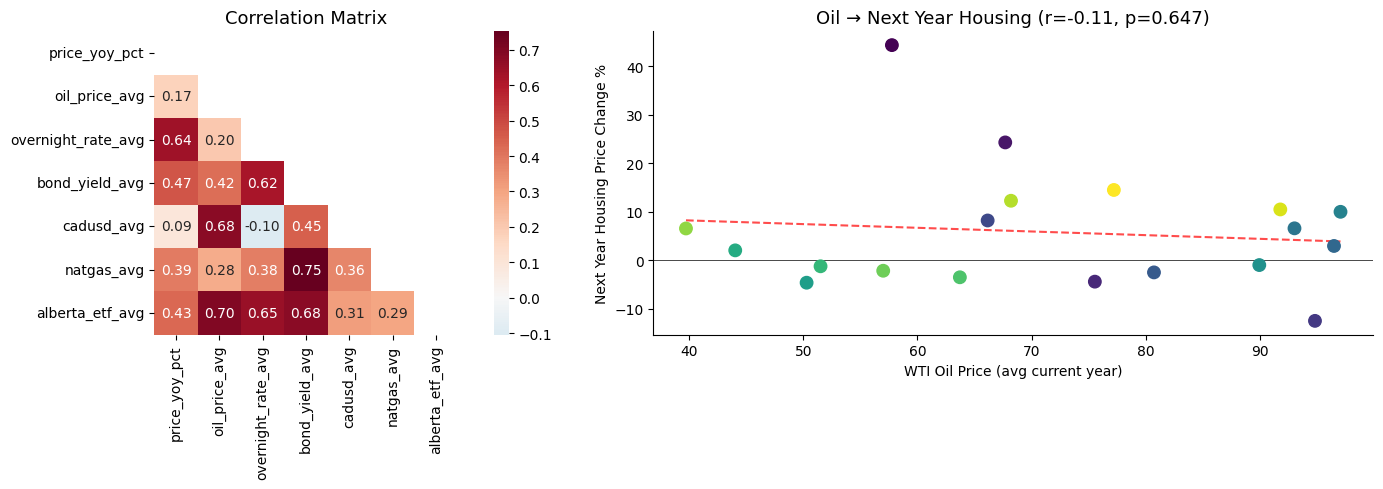


Correlation with next year's housing YoY%:
  oil_price_avg                 : r=-0.112  p=0.647
  overnight_rate_avg            : r=+0.250  p=0.302
  bond_yield_avg                : r=+0.310  p=0.196
  cadusd_avg                    : r=-0.114  p=0.643
  natgas_avg                    : r=+0.367  p=0.122
  alberta_etf_avg               : r=-0.010  p=0.966


In [4]:
# Lag correlations: does oil from year T predict housing in year T+1?
features = ['oil_price_avg', 'overnight_rate_avg', 'bond_yield_avg', 'cadusd_avg', 'natgas_avg', 'alberta_etf_avg']

corr_data = annual[['price_yoy_pct'] + features].dropna()

# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=axes[0], square=True)
axes[0].set_title('Correlation Matrix', fontsize=13)

# Scatter: oil vs next year housing change
ax = axes[1]
annual_clean = annual.dropna(subset=['oil_price_avg', 'next_year_yoy_pct'])
ax.scatter(annual_clean['oil_price_avg'], annual_clean['next_year_yoy_pct'],
           c=annual_clean['roll_year'], cmap='viridis', s=80, zorder=5)

# Regression line
slope, intercept, r, p, _ = stats.linregress(annual_clean['oil_price_avg'], annual_clean['next_year_yoy_pct'])
x_line = np.linspace(annual_clean['oil_price_avg'].min(), annual_clean['oil_price_avg'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7)
ax.set_xlabel('WTI Oil Price (avg current year)')
ax.set_ylabel('Next Year Housing Price Change %')
ax.set_title(f'Oil → Next Year Housing (r={r:.2f}, p={p:.3f})', fontsize=13)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\nCorrelation with next year's housing YoY%:")
for col in features:
    valid = annual.dropna(subset=[col, 'next_year_yoy_pct'])
    if len(valid) > 5:
        r, p = stats.pearsonr(valid[col], valid['next_year_yoy_pct'])
        print(f"  {col:30s}: r={r:+.3f}  p={p:.3f}")

## 4. Monthly CREB Data (2025-2026)

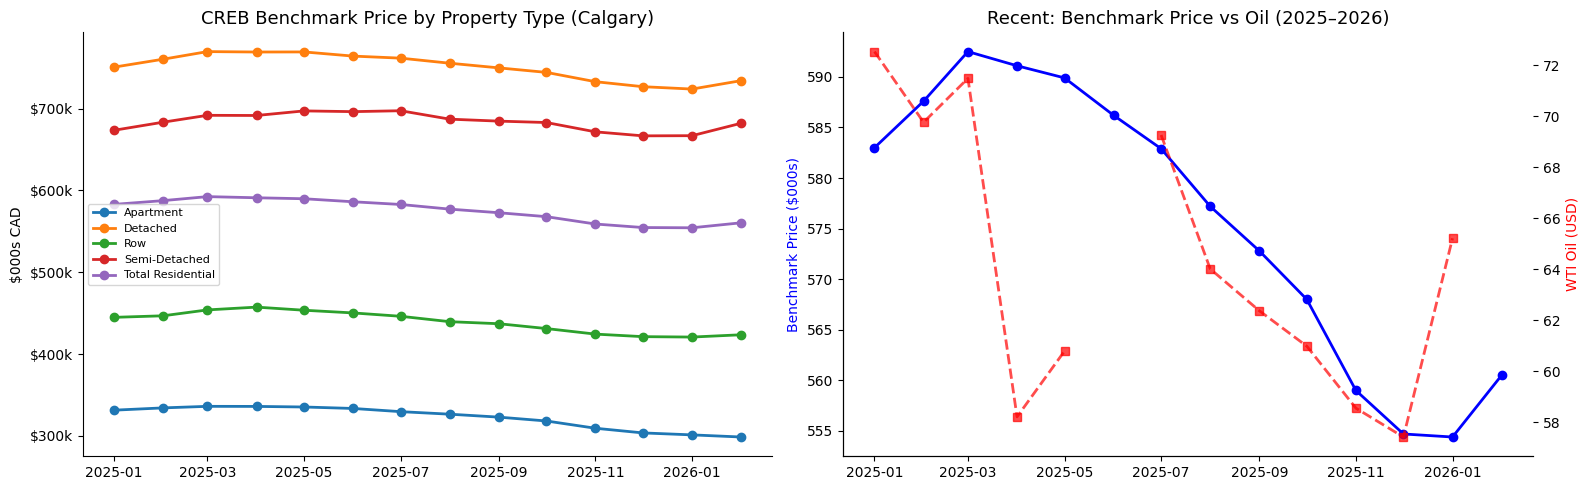


Latest benchmark prices:
    property_type  benchmark_price  sales  inventory
        Apartment         298600.0  345.0     1580.0
         Detached         734300.0  736.0     1941.0
              Row         423600.0  270.0      887.0
    Semi-Detached         682200.0  175.0      414.0
Total Residential         560500.0 1526.0     4822.0


In [5]:
# Benchmark price by property type
prop_types = monthly['property_type'].unique()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Benchmark prices by property type
ax = axes[0]
for prop in prop_types:
    subset = monthly[monthly['property_type'] == prop].sort_values('date')
    ax.plot(subset['date'], subset['benchmark_price'] / 1000, 'o-', label=prop, linewidth=2)
ax.set_title('CREB Benchmark Price by Property Type (Calgary)', fontsize=13)
ax.set_ylabel('$000s CAD')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:.0f}k'))

# Oil vs benchmark (total residential)
ax = axes[1]
tres = monthly[monthly['property_type'] == 'Total Residential'].sort_values('date')
ax.plot(tres['date'], tres['benchmark_price'] / 1000, 'b-o', linewidth=2, label='Total Residential')
ax2 = ax.twinx()
ax2.plot(tres['date'], tres['oil_price_usd'], 'r--s', linewidth=2, alpha=0.7, label='WTI Oil')
ax.set_title('Recent: Benchmark Price vs Oil (2025–2026)', fontsize=13)
ax.set_ylabel('Benchmark Price ($000s)', color='blue')
ax2.set_ylabel('WTI Oil (USD)', color='red')

plt.tight_layout()
plt.show()

# Summary stats
print("\nLatest benchmark prices:")
latest = monthly[monthly['date'] == monthly['date'].max()]
print(latest[['property_type', 'benchmark_price', 'sales', 'inventory']].to_string(index=False))

## 5. Key Findings

Summary of correlations and patterns found — to inform model features.

In [6]:
# Feature importance preview — correlation with next year price change
print("=== Key Observations ===")
print()

# Oil crash years
oil_crash = annual[annual['oil_price_avg'] < 50]
oil_boom = annual[annual['oil_price_avg'] > 80]

print(f"When oil avg < $50: avg next-year housing change = {oil_crash['next_year_yoy_pct'].mean():.1f}%")
print(f"When oil avg > $80: avg next-year housing change = {oil_boom['next_year_yoy_pct'].mean():.1f}%")
print()

# Rate hike impact
high_rate = annual[annual['overnight_rate_avg'] > 3]
low_rate = annual[annual['overnight_rate_avg'] < 1]

print(f"When overnight rate > 3%: avg next-year housing change = {high_rate['next_year_yoy_pct'].mean():.1f}%")
print(f"When overnight rate < 1%: avg next-year housing change = {low_rate['next_year_yoy_pct'].mean():.1f}%")

=== Key Observations ===

When oil avg < $50: avg next-year housing change = 4.3%
When oil avg > $80: avg next-year housing change = 2.0%

When overnight rate > 3%: avg next-year housing change = 11.5%
When overnight rate < 1%: avg next-year housing change = 2.9%
